1.准备数据（学习时间vs学习分数）

In [2]:
import numpy as np

X = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([52, 55, 61, 65, 69, 74, 78, 82])

2.数据可视化

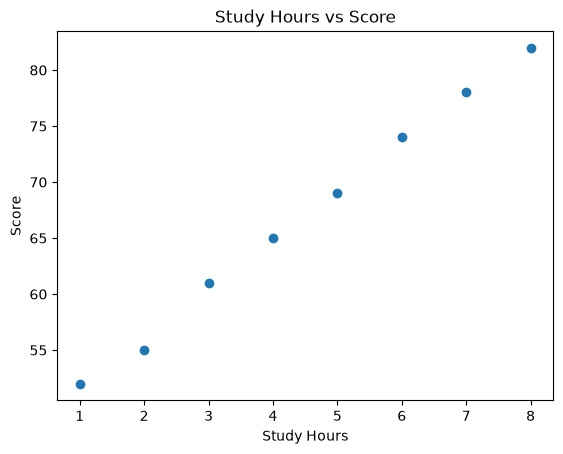

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Study Hours vs Score")

plt.show()

3.调用sklearn的线性回归模型训练

In [5]:
from sklearn import set_config
from sklearn.linear_model import LinearRegression

set_config(display="text")

model = LinearRegression()

model.fit(X.reshape(-1, 1), y)
print("截距 b0 =", model.intercept_)
print("斜率 b1 =", model.coef_[0])

截距 b0 = 47.28571428571428
斜率 b1 = 4.380952380952382


4.用线性回归模型预测第4.5小时（x_new）的成绩

In [8]:
x_new = 4.5

y_pred = model.intercept_ + model.coef_[0] * x_new

print("学习5小时，预测成绩 =", y_pred)

69.19047619047619


5.画出线性回归曲线

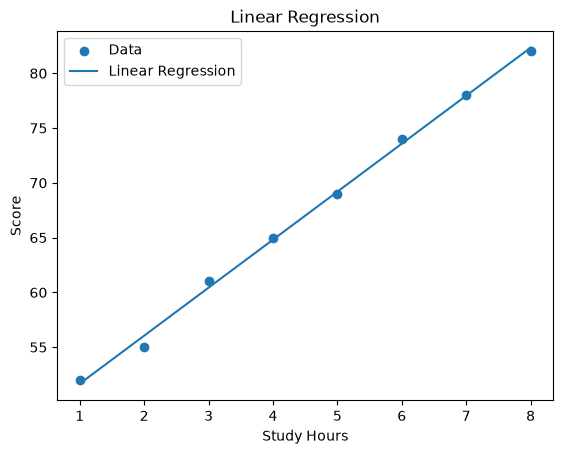

In [9]:
import matplotlib.pyplot as plt

# 生成回归直线上的 x
x_line = np.linspace(X.min(), X.max(), 100)

# 根据模型计算预测值
y_line = model.predict(x_line.reshape(-1, 1))

# 原始数据
plt.scatter(X, y, label="Data")

# 回归直线
plt.plot(x_line, y_line, label="Linear Regression")

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Linear Regression")

plt.legend()
plt.show()

一.误差分析，计算真实值与预测值以及误差

In [10]:
y_pred = model.predict(X.reshape(-1, 1))

print("真实值：")
print(y)

print("\n预测值：")
print(y_pred)

print("\n误差：")
print(y - y_pred)

真实值：
[52 55 61 65 69 74 78 82]

预测值：
[51.66666667 56.04761905 60.42857143 64.80952381 69.19047619 73.57142857
 77.95238095 82.33333333]

误差：
[ 0.33333333 -1.04761905  0.57142857  0.19047619 -0.19047619  0.42857143
  0.04761905 -0.33333333]


In [ ]:
计算误差平方和（SSE）:SSE = sum((y - y_pred) ** 2)

In [11]:
y_pred = model.predict(X.reshape(-1, 1))

errors = y - y_pred

sse = np.sum(errors ** 2)

print("预测值：")
print(y_pred)

print("\n误差：")
print(errors)

print("\n误差平方和 SSE：")
print(sse)

预测值：
[51.66666667 56.04761905 60.42857143 64.80952381 69.19047619 73.57142857
 77.95238095 82.33333333]

误差：
[ 0.33333333 -1.04761905  0.57142857  0.19047619 -0.19047619  0.42857143
  0.04761905 -0.33333333]

误差平方和 SSE：
1.904761904761917


计算均方根误差MSE:MSE = SSE/n

In [12]:
mse = np.mean((y - y_pred) ** 2)

print("MSE =", mse)

MSE = 0.23809523809523964


三.模型对比：线性回归核心思想：在线性模型的所有可能参数中，寻找一组b0与b1，使预测值和真实值之间的平方误差平均起来最小。

In [13]:
# 真实模型
y_pred_best = 47.2857 + 4.3810 * X

# 故意制造两条不太好的直线
y_pred_1 = 40 + 5 * X
y_pred_2 = 55 + 2.5 * X

mse_best = np.mean((y - y_pred_best) ** 2)
mse_1 = np.mean((y - y_pred_1) ** 2)
mse_2 = np.mean((y - y_pred_2) ** 2)

print("我们的模型 MSE =", mse_best)
print("直线1 MSE =", mse_1)
print("直线2 MSE =", mse_2)

我们的模型 MSE = 0.23809529000000026
直线1 MSE = 22.5
直线2 MSE = 19.375
